## KD Tree vs KNN

Brute-force avg time: 0.175 ms
KD-Tree avg time: 0.059 ms


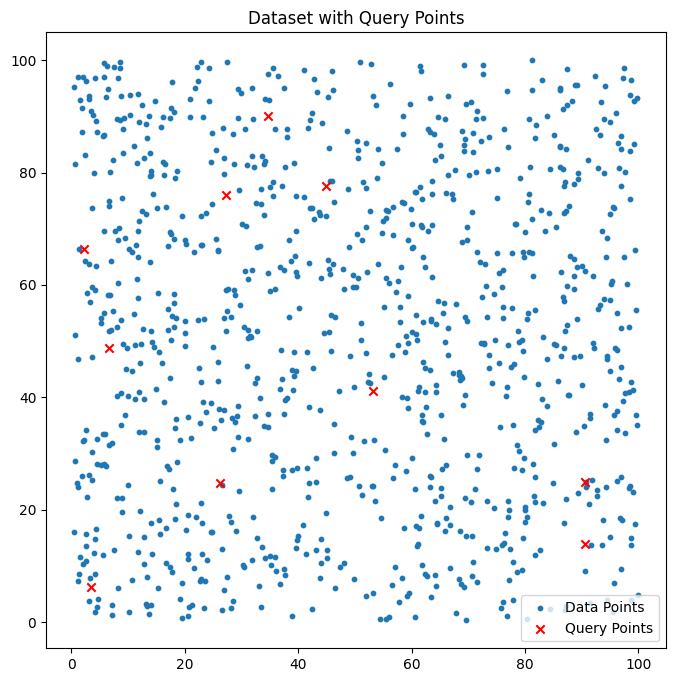

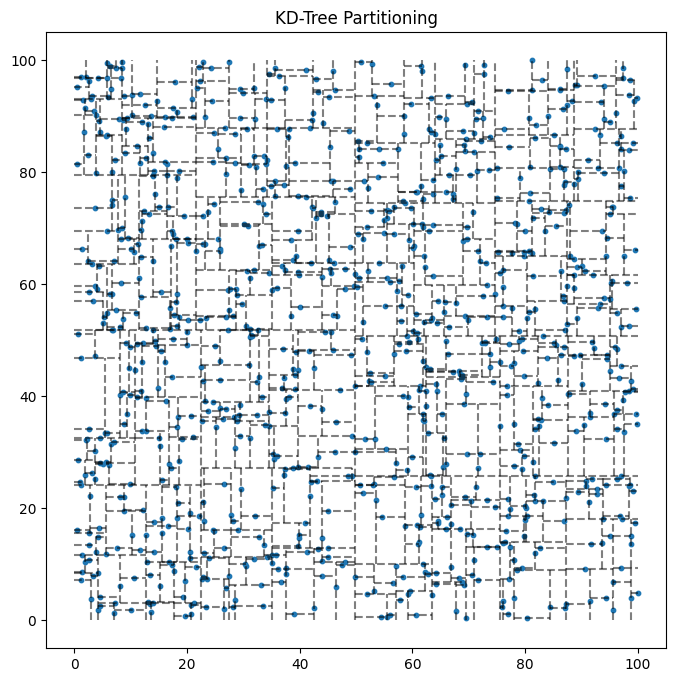

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.spatial import KDTree
from sklearn.neighbors import NearestNeighbors

# Generate synthetic 2D dataset
np.random.seed(42)
n_samples = 1000  # Number of data points
data = np.random.rand(n_samples, 2) * 100  # 2D points in a 100x100 area

# Generate some random query points
n_queries = 10
queries = np.random.rand(n_queries, 2) * 100

# Brute-force KNN implementation
def brute_force_knn(data, query, k=1):
    distances = np.linalg.norm(data - query, axis=1)  # Compute Euclidean distances
    indices = np.argsort(distances)[:k]  # Get indices of k nearest neighbors
    return indices, distances[indices]

# KD-Tree based KNN implementation
def kd_tree_knn(tree, query, k=1):
    distances, indices = tree.query(query, k)
    return indices, distances

# Build the KD-Tree
tree = KDTree(data)

# Compare execution times
k = 5  # Number of neighbors
brute_force_times = []
kdtree_times = []

for query in queries:
    start = time.time()
    brute_force_knn(data, query, k)
    brute_force_times.append(time.time() - start)
    
    start = time.time()
    kd_tree_knn(tree, query, k)
    kdtree_times.append(time.time() - start)

print(f"Brute-force avg time: {np.mean(brute_force_times) * 1e3:.3f} ms")
print(f"KD-Tree avg time: {np.mean(kdtree_times) * 1e3:.3f} ms")

# Visualization of the dataset
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], s=10, label='Data Points')
plt.scatter(queries[:, 0], queries[:, 1], c='red', marker='x', label='Query Points')
plt.legend()
plt.title("Dataset with Query Points")
plt.show()

# Visualize KD-Tree partitioning
def plot_kdtree(tree, data, depth=0, xlim=(0, 100), ylim=(0, 100)):
    if len(data) == 0:
        return
    
    axis = depth % 2  # Alternate between x and y
    sorted_data = data[data[:, axis].argsort()]
    median_idx = len(sorted_data) // 2
    median_point = sorted_data[median_idx]
    
    if axis == 0:
        plt.plot([median_point[0], median_point[0]], ylim, 'k--', alpha=0.5)
        plot_kdtree(tree, sorted_data[:median_idx], depth+1, (xlim[0], median_point[0]), ylim)
        plot_kdtree(tree, sorted_data[median_idx+1:], depth+1, (median_point[0], xlim[1]), ylim)
    else:
        plt.plot(xlim, [median_point[1], median_point[1]], 'k--', alpha=0.5)
        plot_kdtree(tree, sorted_data[:median_idx], depth+1, xlim, (ylim[0], median_point[1]))
        plot_kdtree(tree, sorted_data[median_idx+1:], depth+1, xlim, (median_point[1], ylim[1]))
    
plt.figure(figsize=(8, 8))
plt.scatter(data[:, 0], data[:, 1], s=10)
plot_kdtree(tree, data)
plt.title("KD-Tree Partitioning")
plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.spatial import KDTree

# --- NEW: FAISS ---
import faiss

# Generate synthetic 2D dataset
np.random.seed(42)
n_samples = 100000
data = np.random.rand(n_samples, 20) * 100

n_queries = 10
queries = np.random.rand(n_queries, 20) * 100

# Brute-force KNN implementation
def brute_force_knn(data, query, k=1):
    distances = np.linalg.norm(data - query, axis=1)
    indices = np.argsort(distances)[:k]
    return indices, distances[indices]

# KD-Tree based KNN implementation
def kd_tree_knn(tree, query, k=1):
    distances, indices = tree.query(query, k)
    return indices, distances

# --- NEW: FAISS KNN ---
def faiss_knn(index, query, k=1):
    # FAISS expects shape (nq, d) float32
    q = np.asarray(query, dtype=np.float32).reshape(1, -1)
    D, I = index.search(q, k)  # squared L2 distances for L2 index
    return I[0], D[0]

# Build KD-Tree
tree = KDTree(data)

# --- NEW: Build FAISS index ---
# FAISS prefers float32, contiguous
data_f32 = np.ascontiguousarray(data.astype(np.float32))
queries_f32 = np.ascontiguousarray(queries.astype(np.float32))

d = data_f32.shape[1]  # dimension = 2

# Option A: exact search (brute force on FAISS backend)
faiss_index = faiss.IndexFlatL2(d)
faiss_index.add(data_f32)

# Compare execution times
k = 5
brute_force_times = []
kdtree_times = []
faiss_times = []

for query in queries:
    start = time.perf_counter()
    brute_force_knn(data, query, k)
    brute_force_times.append(time.perf_counter() - start)

    start = time.perf_counter()
    kd_tree_knn(tree, query, k)
    kdtree_times.append(time.perf_counter() - start)

# --- NEW: time FAISS (use queries_f32 to avoid per-query casting cost) ---
for q in queries_f32:
    start = time.perf_counter()
    faiss_knn(faiss_index, q, k)
    faiss_times.append(time.perf_counter() - start)

print(f"Brute-force avg time: {np.mean(brute_force_times) * 1e3:.3f} ms")
print(f"KD-Tree avg time:     {np.mean(kdtree_times) * 1e3:.3f} ms")
print(f"FAISS (FlatL2) avg:   {np.mean(faiss_times) * 1e3:.3f} ms")

# (Optional) correctness sanity check for the first query
bf_idx, bf_dist = brute_force_knn(data, queries[0], k)
kd_idx, kd_dist = kd_tree_knn(tree, queries[0], k)
fa_idx, fa_D = faiss_knn(faiss_index, queries_f32[0], k)

print("\nSanity check (first query):")
print("Brute idx:", bf_idx)
print("KDTree idx:", kd_idx)
print("FAISS idx:", fa_idx)

# Note: FAISS IndexFlatL2 returns squared L2 distances; brute/KDTree return L2.
# If you want to compare distances:
print("Brute dist (L2):", bf_dist)
print("KDTree dist (L2):", kd_dist)
print("FAISS dist (sqrt(L2^2)):", np.sqrt(fa_D))


Brute-force avg time: 8.112 ms
KD-Tree avg time:     4.666 ms
FAISS (FlatL2) avg:   0.253 ms

Sanity check (first query):
Brute idx: [51447 65143 91665  7195 98551]
KDTree idx: [51447 65143 91665  7195 98551]
FAISS idx: [51447 65143 91665  7195 98551]
Brute dist (L2): [76.0814369  82.75720564 83.10254119 83.80563636 86.69138366]
KDTree dist (L2): [76.0814369  82.75720564 83.10254119 83.80563636 86.69138366]
FAISS dist (sqrt(L2^2)): [76.081436 82.75721  83.10255  83.80564  86.69138 ]
